In [2]:
import sys
import ugradio
import pandas as pd
from rtlsdr import RtlSdr
import asyncio
import time
import numpy as np
import matplotlib.pyplot as plt

/home/radiopi/miniconda3/lib/python3.13/site-packages/rtlsdr/__init__.py:19: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [3]:
import ugradio.sdr as sdr
import ugradio.dft as dft

(1.0, 100.0)

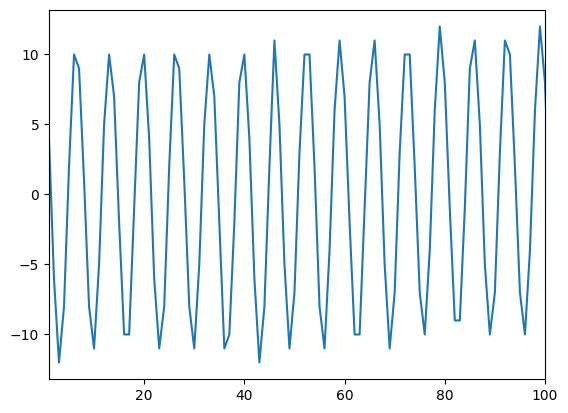

In [4]:
data = np.load("poopoo.npz")
D = 1 #what sample set (1, 2, 3, 4, or 5)

plt.plot(range(len(data["arr_0"][D])), data["arr_0"][D])
# plt.plot(range(len(data["arr_0"][0])), data["arr_0"][0])
plt.xlim(1, 100)

#plt.savefig('sinewave_notzoom.png', bbox_inches='tight')
#plt.show()


/home/radiopi/miniconda3/lib/python3.13/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/radiopi/miniconda3/lib/python3.13/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


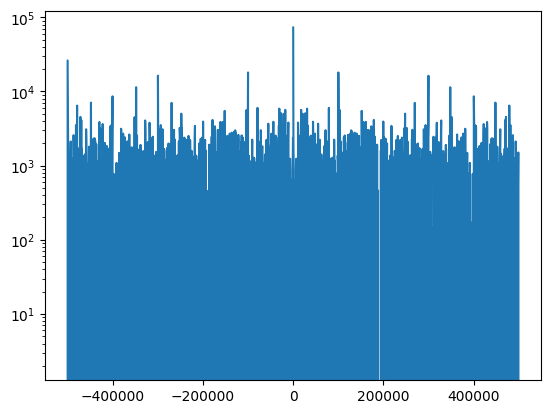

In [11]:
frequencies = np.fft.fftfreq(2048, d=1e-6)
# print(max(np.abs(np.fft.fftfreq(data["arr_0"][D]))**2))
plt.plot(frequencies, np.fft.fft((np.abs(data["arr_0"][D]))**2))

plt.yscale("log")

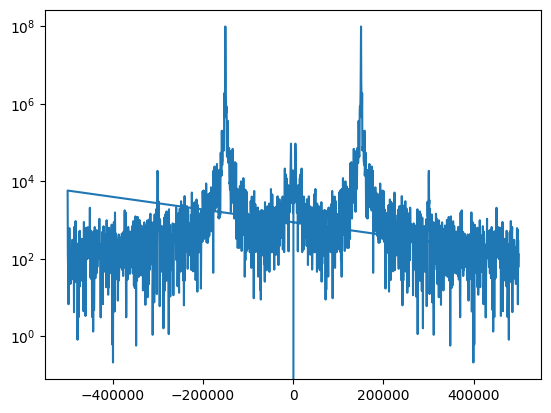

In [8]:
#Ro code, worked on it alongside Ben
#Can fix straking line with fft shift

data_mean_subtracted = data["arr_0"][D] - np.mean(data["arr_0"][D]) #removes central peak from zeroth order first line

frequencies = np.fft.fftfreq(2048, d=1e-6)
# print(max(np.abs(np.fft.fftfreq(data["arr_0"][0]))**2))
plt.plot(frequencies, np.abs(np.fft.fft(data_mean_subtracted))**2)

plt.yscale("log")

plt.savefig('powerspec_log.png', bbox_inches='tight')
plt.show()


In [26]:
ugradio.sdr.SDR?